In [ ]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

import sys
sys.path.append('../')
from neural_net import NeuralNet
import mushrooms as shroom
import graphics

In [2]:
data = load_iris(as_frame=True)
df = data.frame # type: ignore

print("Data shape:", df.shape)
df.head()

Data shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X = df.drop(columns=['target']).to_numpy().astype(np.float64)
y = df["target"].to_numpy()
y_enc = np.eye(np.max(y) + 1)[y]

print("Data shape:", X.shape, y_enc.shape, "Categories: ", data.target_names) #type: ignore

Data shape: (150, 4) (150, 3) Categories:  ['setosa' 'versicolor' 'virginica']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, stratify=y_enc, random_state=42)

In [5]:
neural_net = NeuralNet((4, 32, 3), learning_rate = 0.01, random_state=42)
neural_net.layers[-1].activation_method="softmax"
epochs = 20
losses, y_pred = neural_net.train(X_train, y_train, epochs, 1, validate=(X_test, y_test), categorical=True)

EPOCH: 1    LOSS: 0.508205    LOSS CHANGE: 0    TEST ACCURACY: 0.6667    TEST ACCURACY CHANGE 0.6667
EPOCH: 2    LOSS: 0.315312    LOSS CHANGE: -0.1929    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0.3
EPOCH: 3    LOSS: 0.231057    LOSS CHANGE: -0.08425    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0
EPOCH: 4    LOSS: 0.172468    LOSS CHANGE: -0.05859    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0
EPOCH: 5    LOSS: 0.156715    LOSS CHANGE: -0.01575    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0
EPOCH: 6    LOSS: 0.158585    LOSS CHANGE: 0.00187    TEST ACCURACY: 0.9333    TEST ACCURACY CHANGE -0.03333
EPOCH: 7    LOSS: 0.114669    LOSS CHANGE: -0.04392    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0.03333
EPOCH: 8    LOSS: 0.0909513    LOSS CHANGE: -0.02372    TEST ACCURACY: 0.9333    TEST ACCURACY CHANGE -0.03333
EPOCH: 9    LOSS: 0.0769863    LOSS CHANGE: -0.01396    TEST ACCURACY: 0.9667    TEST ACCURACY CHANGE 0.03333
EPOCH: 10    LOSS: 0.123362    LOSS CHANGE: 0.0

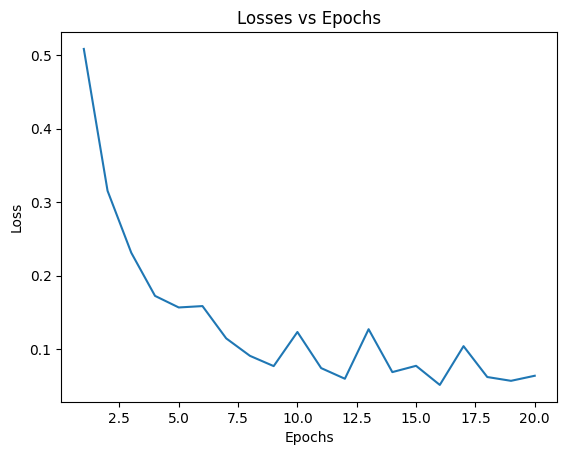

In [6]:
graphics.plot_losses(epochs, losses)

In [7]:
y_pred = neural_net.predict(X)
predicted = np.argmax(y_pred, axis=1)

df["predicted"] = predicted # type:ignore
df["names"] = data.target_names[df["target"]] # type:ignore
df["predicted names"] = data.target_names[predicted] # type:ignore
display(df[df["predicted"] != df["target"]])

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,predicted,names,predicted names
70,5.9,3.2,4.8,1.8,1,2,versicolor,virginica
72,6.3,2.5,4.9,1.5,1,2,versicolor,virginica
83,6.0,2.7,5.1,1.6,1,2,versicolor,virginica


<Figure size 800x600 with 0 Axes>

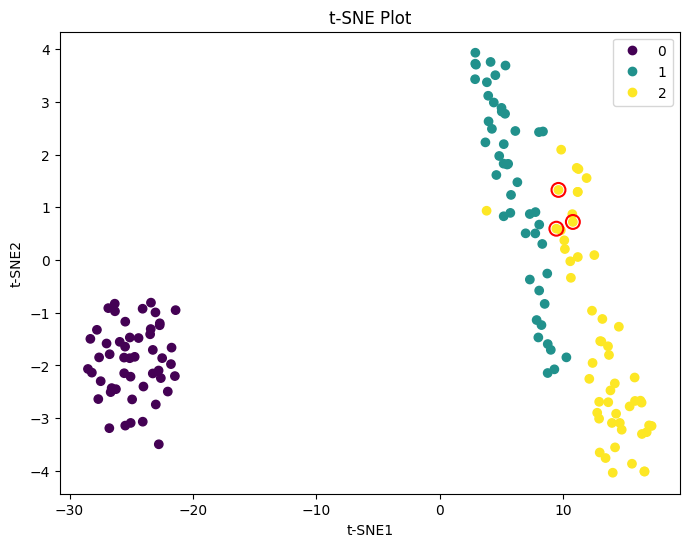

In [10]:
from sklearn.manifold import TSNE
import matplotlib.patches as patches

def t_sne(df, df_target):
    plt.figure(figsize=(8,6))
    X = df.drop(columns=["target", "names", "predicted names", "predicted"])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_embedded = tsne.fit_transform(X)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0],
                X_embedded[:, 1],
                c=df_target)
    for index in df[df["predicted"] != df["target"]].index:
        plt.scatter(X_embedded[index, 0], X_embedded[index, 1], edgecolor='red', facecolor='none', s=100, linewidth=1.5, label='Misclassified')
    handles, labels = scatter.legend_elements()
    plt.legend(handles=handles, labels=labels)
    plt.title('t-SNE Plot')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.show()

t_sne(df, df["predicted"])